# Main Practice NoteBook - Finding Child Category

###  Step 1 - Importing Libraries

In [60]:
# import basic libraries for data reading, and analysis
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#import pre-processing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# importing models training libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# importing model accuracy testing libraries and summary information generator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

### Step 2 - Load Dataset

In [38]:
# Load the data set
file_path = "./data.csv"
data = pd.read_csv(file_path)

In [39]:
# Data summary print (overall information)
print("Data Overall View: ")
data.describe()


#print("Show first few rows: ")
#data.head()



Data Overall View: 


,Length(cm),weight(Kg)
count,896.000000,896.000000
mean,82.500000,9.981696
std,19.017193,4.354809
min,45.000000,1.900000
25%,68.750000,7.000000
50%,82.500000,9.600000
75%,96.250000,12.700000
max,120.000000,22.800000


In [40]:
# Remove the unnamed column if it exists
if 'Unnamed: 5' in data.columns:
    data.drop(columns=['Unnamed: 5'], inplace=True)

# Display the first few rows again to verify the column removal
data.head()

,Gender,Age,Length(cm),weight(Kg),Status
0,Boy,6-23,45,2.4,Normal
1,Boy,6-23,45,2.2,Mild Malnutrition
2,Boy,6-23,45,2.0,Moderate Malnutrition
3,Boy,6-23,45,1.9,Severe Malnutrition
4,Boy,6-23,46,2.6,Normal


In [41]:
# Printing the column names of the cleaned dataset
print("Column Names:")
print(data.columns)

Column Names:
Index(['Gender', 'Age', 'Length(cm)', 'weight(Kg)', 'Status'], dtype='object')


In [42]:
# Check for any missing values 
missing_values = data.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Gender        0
Age           0
Length(cm)    0
weight(Kg)    0
Status        0
dtype: int64


### Data Pre Processing Phase

In [43]:
#Count the occurrences of each class in the 'Status' column

status_counts = data['Status'].value_counts()

print("Class Distribution in 'Status' Column: ")
print(status_counts)

Class Distribution in 'Status' Column: 
Status
Normal                   224
Mild Malnutrition        224
Moderate Malnutrition    224
Severe  Malnutrition     224
Name: count, dtype: int64


In [44]:
# Summary statistics for numerical columns
summary_stats = data[['Length(cm)', 'weight(Kg)']].describe()

print("Summary Statistics:")
print(summary_stats)

Summary Statistics:
       Length(cm)  weight(Kg)
count  896.000000  896.000000
mean    82.500000    9.981696
std     19.017193    4.354809
min     45.000000    1.900000
25%     68.750000    7.000000
50%     82.500000    9.600000
75%     96.250000   12.700000
max    120.000000   22.800000


#### Checking for the outlier from the different column from the dataset but look at length and weight column

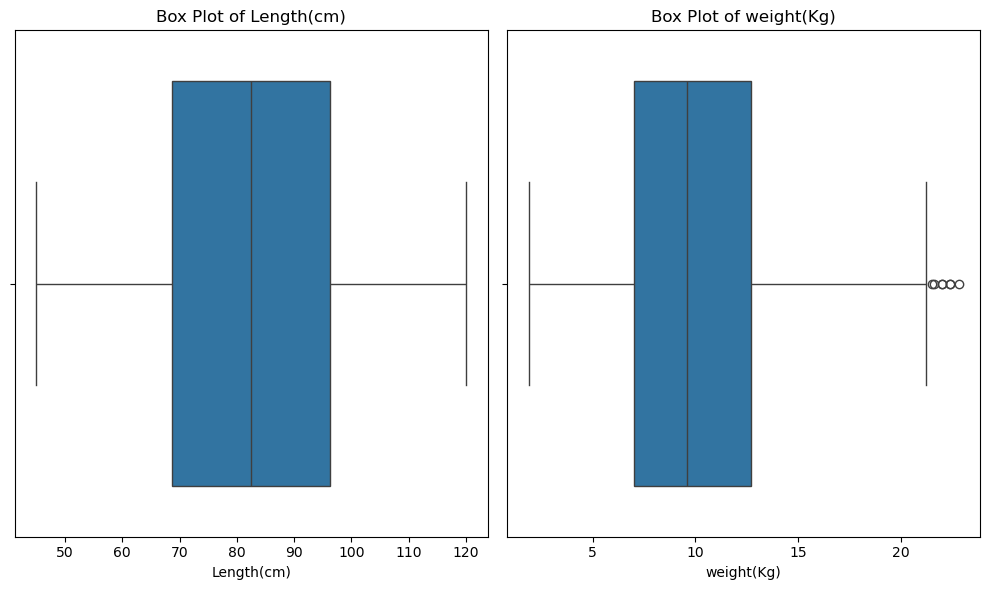

In [45]:
plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
sns.boxplot(x=data['Length(cm)'])
plt.title('Box Plot of Length(cm)')

plt.subplot(1,2,2)
sns.boxplot(x=data['weight(Kg)'])
plt.title('Box Plot of weight(Kg)')

plt.tight_layout()
plt.show()

In [50]:
# Compute Z-scores for the 'Length(cm)' and 'weight(kg)'
z_scores_length = stats.zscore(data['Length(cm)'])
z_scores_weight = stats.zscore(data['weight(Kg)'])

# Identify outliers using a threshold (e.g. Z-score > 3 or < - 3)
outliers_length = (z_scores_length > 3) | (z_scores_length < -3)
outliers_weight = (z_scores_weight > 3) | (z_scores_weight < -3)

# Print indices of outliers 
print("Outliers in Length(cm):")
print(data[outliers_length]['Length(cm)'])


print("\nOutliers in weight(Kg):")
print(data[outliers_weight]['weight(Kg)'])

Outliers in Length(cm):
Series([], Name: Length(cm), dtype: int64)

Outliers in weight(Kg):
Series([], Name: weight(Kg), dtype: float64)


In [51]:
unique_ages = data['Age'].unique()
print("Unique values in 'Age' column:")
print(unique_ages)

Unique values in 'Age' column:
['6-23' '24-59']


In [52]:
# Initializa 'Age_category' column with default values 
data['Age_category'] = ''
# Assign  labels based on conditions
data.loc[data['Age'] == '6-23', 'Age_category'] = 'Young Adults'
data.loc[data['Age'] == '24-59', 'Age_category'] = 'Senior Adults'

#Display first few rows to inspect new column
print(data[['Age', 'Age_category']].head())


    Age  Age_category
0  6-23  Young Adults
1  6-23  Young Adults
2  6-23  Young Adults
3  6-23  Young Adults
4  6-23  Young Adults


In [53]:
print("Column Names:")
print(data.columns)

Column Names:
Index(['Gender', 'Age', 'Length(cm)', 'weight(Kg)', 'Status', 'Age_category'], dtype='object')


### Transform the categorical columns to numerical

In [54]:
# Initialize LabelEncoder 
label_encoder = LabelEncoder()

# Encode 'Gender' and 'Age_category'
data['Gender_encoded'] = label_encoder.fit_transform(data['Gender'])
data['Age_category_encoded'] = label_encoder.fit_transform(data['Age_category'])

# Display first few rows to inspect the encoded columns
print(data[['Gender', 'Gender_encoded', 'Age_category', 'Age_category_encoded']].head())

  Gender  Gender_encoded  Age_category  Age_category_encoded
0    Boy               0  Young Adults                     1
1    Boy               0  Young Adults                     1
2    Boy               0  Young Adults                     1
3    Boy               0  Young Adults                     1
4    Boy               0  Young Adults                     1


#### Feature Engineering 

In [55]:
# Define features (X) and target variable (y)

features = ['Gender_encoded', 'Age_category_encoded', 'Length(cm)', 'weight(Kg)']
X = data[features]
y = data['Status']

# Split dat into trainingg and testing sts (e.g, 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [56]:
print("Training set shape: ", X_train.shape, y_train.shape)
print("Testing set shape: ", X_test.shape, y_test.shape)

Training set shape:  (716, 4) (716,)
Testing set shape:  (180, 4) (180,)


### MODEL TRAINING AND CHOOSING MODEL WITH HIGH ACCURACY

In [ ]:
# Define a list of classifiers with updated parameters

classifiers = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forst', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42))
]


# Evaluate each classifier using cross-validation and test set evaluation 
for clf_name, clf in classifiers:
    # Create a plipline with scaling (if applicable) and the classifier
    if clf_name == 'LogisticRegression':
        pipeline = Pipeline(steps=[('scaler', StandardScaler()), ('classifier', clf)])
    else:
        pipeline = Pipeline(steps=[('classifier', clf)])
    
    # Perform cross-validation with 5 folds 
    scores =  cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

    # Print results
    print(f"{clf_name}:")
    print("Cross-Validation Scores:", scores)
    print("Mean accuracy: ", scores.mean())
    print()

    # Fit the classifier on the whole training data
    pipeline.fit(X_train, y_train)

    # Predictions on test set
    y_pred = pipeline.predict(X_test)

    #Evaluate model performacne on test set 
    print("Evaluation on Test Set:")
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Classifciation Report: ")
    print(classification_report(y_test, y_pred))
    print("--------------------------------------------------\n")
    
